# Module 3: Fine-Tuning BERT for Embedding-Based Retrieval

> **Series:** PyTorch Deep Dive → BERT Fine-Tuning for Embedding-Based Retrieval  
> **Prerequisites:** Modules 1 & 2

---

## What you'll build end-to-end

```
Raw text pairs (query, passage)
       ↓
Tokenisation  (HuggingFace AutoTokenizer)
       ↓
Bi-encoder BERT  (shared weights, mean pooling, projection head)
       ↓
InfoNCE training  (in-batch negatives, mixed-precision)
       ↓
FAISS index  (approximate nearest-neighbour search)
       ↓
Recall@K / MRR evaluation
       ↓
Interactive query demo
```

| # | Section |
|---|---------|
| 1 | Environment & package install |
| 2 | Dataset: MS MARCO mini |
| 3 | Tokenisation & custom Dataset |
| 4 | Bi-encoder model |
| 5 | InfoNCE loss |
| 6 | Training loop (+ mixed precision) |
| 7 | FAISS indexing |
| 8 | Evaluation: Recall@K & MRR |
| 9 | Interactive query demo |


---
## 1 · Environment Setup

Install the required packages (run once):
```bash
pip install torch transformers datasets faiss-cpu matplotlib tqdm
```


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device  : {device}")

# Mixed-precision: AMP (float16) is supported on CUDA only.
# MPS has its own bfloat16 support but GradScaler is not supported there,
# so we fall back to float32 on MPS and CPU.
use_amp = device.type == "cuda"
print(f"AMP     : {use_amp}")


PyTorch : 2.11.0
Device  : mps
AMP     : False


---
## 2 · Dataset: MS MARCO Mini

We use the **MS MARCO passage ranking** dataset — a real information-retrieval benchmark from Microsoft.  
For this tutorial we load a small slice (≤ 5 000 training triples) from HuggingFace Datasets so the notebook runs in minutes on CPU.

Each example is a triple: `(query, positive_passage, negative_passage)`.


In [7]:
try:
    from datasets import load_dataset
    # Download and cache locally — more reliable than streaming over a live HTTP connection.
    # The first run will take ~30 s; subsequent runs load from the HuggingFace cache instantly.
    ds = load_dataset("microsoft/ms_marco", "v1.1", split="train")

    triples = []
    for ex in ds:
        passages    = ex["passages"]
        is_selected = passages["is_selected"]
        texts       = passages["passage_text"]
        pos_indices = [i for i, s in enumerate(is_selected) if s == 1]
        neg_indices = [i for i, s in enumerate(is_selected) if s == 0]
        if pos_indices and neg_indices:
            triples.append({
                "query":    ex["query"],
                "positive": texts[pos_indices[0]],
                "negative": texts[neg_indices[0]],
            })
        if len(triples) >= 5000:
            break

    print(f"Loaded {len(triples):,} triples from MS MARCO")
    print("\nExample:")
    print(f"  query    : {triples[0]['query'][:80]}")
    print(f"  positive : {triples[0]['positive'][:80]}...")
    print(f"  negative : {triples[0]['negative'][:80]}...")

except Exception as e:
    print(f"Could not load MS MARCO ({e})\nFalling back to synthetic data.")
    import random, string

    def _fake(n=60):
        return " ".join("".join(random.choices(string.ascii_lowercase, k=5)) for _ in range(n // 5))

    triples = [{"query": _fake(20), "positive": _fake(60), "negative": _fake(60)} for _ in range(500)]
    print(f"Using {len(triples)} synthetic triples.")


Generating test split: 100%|██████████| 9650/9650 [00:00<00:00, 459280.74 examples/s]


Loaded 5,000 triples from MS MARCO

Example:
  query    : what is rba
  positive : Results-Based Accountability® (also known as RBA) is a disciplined way of thinki...
  negative : Since 2007, the RBA's outstanding reputation has been affected by the 'Securency...


---
## 3 · Tokenisation & Custom Dataset

`AutoTokenizer` converts raw strings into token IDs and attention masks that BERT understands.

> **Why `max_length=128`?** BERT has quadratic attention complexity in sequence length. Passages longer than 128 tokens are truncated — a practical trade-off for speed. In production, models like Longformer or sliding-window approaches handle longer texts.


In [14]:
from transformers import AutoTokenizer

MODEL_NAME  = "bert-base-uncased"
MAX_Q_LEN   = 64  # query
MAX_P_LEN   = 128 # passage

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Inspect what the tokenizer produces
sample_query = triples[0]["query"]
enc = tokenizer(
    sample_query,
    max_length=MAX_Q_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt", # PyTorch
)
print(f"Sample query  : {sample_query}")
print("Keys          :", list(enc.keys()))
print("input_ids     :", enc["input_ids"][0][:15], "...")
print("attention_mask:", enc["attention_mask"][0][:15], "...")
print(f"Decoded       : {tokenizer.decode(enc['input_ids'][0], skip_special_tokens=True)[:60]}")


Sample query  : what is rba
Keys          : ['input_ids', 'token_type_ids', 'attention_mask']
input_ids     : tensor([  101,  2054,  2003, 21144,  2050,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0]) ...
attention_mask: tensor([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]) ...
Decoded       : what is rba


In [15]:
class RetrievalDataset(Dataset):
    """
    Returns tokenised (query, positive_passage, negative_passage) triples.
    """

    def __init__(self, triples: list[dict], tokenizer, max_q: int, max_p: int):
        self.triples   = triples
        self.tokenizer = tokenizer
        self.max_q     = max_q
        self.max_p     = max_p

    def __len__(self) -> int:
        return len(self.triples)

    def _encode(self, text: str, max_len: int) -> dict:
        return self.tokenizer(
            text,
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

    def __getitem__(self, idx: int) -> dict:
        item = self.triples[idx]
        q    = self._encode(item["query"],    self.max_q)
        pos  = self._encode(item["positive"], self.max_p)
        neg  = self._encode(item["negative"], self.max_p)

        return {
            "q_ids":    q["input_ids"].squeeze(0),
            "q_mask":   q["attention_mask"].squeeze(0),
            "pos_ids":  pos["input_ids"].squeeze(0),
            "pos_mask": pos["attention_mask"].squeeze(0),
            "neg_ids":  neg["input_ids"].squeeze(0),
            "neg_mask": neg["attention_mask"].squeeze(0),
        }


# Split 90/10 train/val
split = int(0.9 * len(triples))
train_ds = RetrievalDataset(triples[:split],  tokenizer, MAX_Q_LEN, MAX_P_LEN)
val_ds   = RetrievalDataset(triples[split:],  tokenizer, MAX_Q_LEN, MAX_P_LEN)

BATCH_SIZE = 16
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train triples : {len(train_ds):,}  ({len(train_dl)} batches)")
print(f"Val   triples : {len(val_ds):,}  ({len(val_dl)} batches)")
batch = next(iter(train_dl))
print(f"q_ids shape   : {batch['q_ids'].shape}")


Train triples : 4,500  (282 batches)
Val   triples : 500  (32 batches)
q_ids shape   : torch.Size([16, 64])


---
## 4 · Bi-Encoder Model Architecture

```
Query ──► BERT encoder ──► mean pool ──► projection head ──► L2-normalise ──► q̂  ┐
                                                                                   ├─► InfoNCE
Doc   ──► BERT encoder ──► mean pool ──► projection head ──► L2-normalise ──► d̂  ┘
```

We use **shared weights** for both query and document — one BERT processes everything. This halves the parameter count and works well in practice (DPR uses separate encoders; SimCSE uses shared).

The **projection head** maps `hidden_size=768` to `embedding_dim=256` — lower dimensionality speeds up FAISS search at essentially no quality cost.


In [30]:
from transformers import AutoModel

class BiEncoder(nn.Module):
    """
    Bi-encoder for dense retrieval.
    Shared BERT backbone, mean pooling, linear projection, L2-normalisation.
    """

    def __init__(self, model_name: str = "bert-base-uncased", embedding_dim: int = 256):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden    = self.bert.config.hidden_size        # 768 for bert-base

        self.proj = nn.Sequential(
            nn.Linear(hidden, embedding_dim),
            nn.LayerNorm(embedding_dim),
        )

    @staticmethod
    def _mean_pool(token_emb: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Average non-padding token embeddings."""
        m    = mask.unsqueeze(-1).float()
        return (token_emb * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def encode(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """Encode a batch of texts → L2-normalised embeddings (B, D)."""
        outputs  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = self._mean_pool(outputs.last_hidden_state, attention_mask)
        return F.normalize(self.proj(pooled), p=2, dim=-1)

    def forward(self, q_ids, q_mask, pos_ids, pos_mask, neg_ids=None, neg_mask=None):
        q_emb   = self.encode(q_ids,   q_mask)
        pos_emb = self.encode(pos_ids, pos_mask)
        neg_emb = self.encode(neg_ids, neg_mask) if neg_ids is not None else None
        return q_emb, pos_emb, neg_emb


model = BiEncoder(MODEL_NAME, embedding_dim=256).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Quick shape test
with torch.no_grad():
    b   = {k: v.to(device) for k, v in batch.items()}
    q_e, p_e, n_e = model(b["q_ids"], b["q_mask"],
                          b["pos_ids"], b["pos_mask"],
                          b["neg_ids"], b["neg_mask"])
print(f"Query emb shape : {q_e.shape}")    # (16, 256)
print(f"L2 norm check   : {q_e.norm(dim=-1)[:4]}")  # all ≈ 1.0


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31244.53it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 109,679,616
Query emb shape : torch.Size([16, 256])
L2 norm check   : tensor([1.0000, 1.0000, 1.0000, 1.0000], device='mps:0')


---
## 5 · InfoNCE Loss

We concatenate positives and negatives along the document axis to give each query $2N - 1$ negatives (all other positives + all negatives) instead of just $N - 1$.  
This **doubles the effective negatives** for free.

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(q_i \cdot d_i^+ / \tau)}{\sum_{j=1}^{2N} \exp(q_i \cdot d_j / \tau)}$$


In [31]:
class InfoNCELoss(nn.Module):
    """
    In-batch InfoNCE loss with optional hard negatives.

    When hard negatives are provided they are appended to the document
    column, giving each query N-1 in-batch negatives + N hard negatives.
    """

    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.tau = temperature

    def forward(self,
                q_emb:   torch.Tensor,          # (N, D)
                pos_emb: torch.Tensor,           # (N, D)
                neg_emb: torch.Tensor | None = None,  # (N, D) optional
               ) -> torch.Tensor:

        N = q_emb.size(0)

        if neg_emb is not None:
            # Docs column: [positives | negatives]  →  (2N, D)
            doc_emb = torch.cat([pos_emb, neg_emb], dim=0)
        else:
            doc_emb = pos_emb

        # (N, 2N) or (N, N) similarity matrix
        logits  = (q_emb @ doc_emb.T) / self.tau

        # Target: diagonal entries (each query's positive is column i)
        targets = torch.arange(N, device=q_emb.device)

        return F.cross_entropy(logits, targets)


criterion = InfoNCELoss(temperature=0.07)

# Sanity check: perfectly aligned embeddings should give ~0 loss
perfect_q = F.normalize(torch.randn(8, 256), dim=-1)
loss_bad  = criterion(perfect_q, F.normalize(torch.randn(8, 256), dim=-1))
loss_good = criterion(perfect_q, perfect_q)
print(f"Loss (random docs)  : {loss_bad.item():.4f}  ← high")
print(f"Loss (perfect match): {loss_good.item():.4f}  ← near 0")


Loss (random docs)  : 2.2249  ← high
Loss (perfect match): 0.0000  ← near 0


---
## 6 · Training Loop

### Mixed-precision training

On CUDA, `torch.cuda.amp` lets us run the forward pass in **float16** (2× memory, 2× throughput on tensor cores) while keeping a float32 master copy of parameters for the gradient update:

```python
with autocast():          # runs in fp16
    loss = ...
scaler.scale(loss).backward()   # scale gradients to avoid fp16 underflow
scaler.step(optimizer)
scaler.update()
```

### Gradient accumulation

When `GRAD_ACCUM = 4`, we run 4 mini-batches before calling `optimizer.step()`, effectively quadrupling the batch size without extra memory.


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, SequentialLR

# Hyperparameters
LR         = 2e-5
EPOCHS     = 3
GRAD_ACCUM = 2     # effective batch = BATCH_SIZE * GRAD_ACCUM

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Linear warmup for 10% of steps, then constant
total_steps  = len(train_dl) * EPOCHS // GRAD_ACCUM
warmup_steps = total_steps // 10
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)
decay_sched  = LinearLR(optimizer, start_factor=1.0, end_factor=0.0, total_iters=total_steps - warmup_steps)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, decay_sched], milestones=[warmup_steps])

scaler = GradScaler(enabled=use_amp)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ---- Train ----
    model.train()
    running_loss, steps = 0.0, 0

    for i, batch in enumerate(tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS} train")):
        b = {k: v.to(device) for k, v in batch.items()}

        # 1. (Gradients already cleared by zero_grad at end of previous accumulation window)
        # 2. Forward pass (fp16 inside autocast on CUDA)
        with autocast(device_type=device.type, enabled=use_amp):
            q_emb, pos_emb, neg_emb = model(
                b["q_ids"], b["q_mask"],
                b["pos_ids"], b["pos_mask"],
                b["neg_ids"], b["neg_mask"],
            )
            # 3. Loss — divide now so accumulated gradients average correctly
            loss = criterion(q_emb, pos_emb, neg_emb) / GRAD_ACCUM

        # 4. Backward pass — scaler inflates gradients to avoid fp16 underflow
        scaler.scale(loss).backward()

        if (i + 1) % GRAD_ACCUM == 0:
            # 5. Optimizer step (every GRAD_ACCUM mini-batches)
            scaler.unscale_(optimizer)                          # restore true gradient scale
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # clip before step
            scaler.step(optimizer)                              # update weights
            scaler.update()                                     # adjust loss scale for next iter
            optimizer.zero_grad()                               # 1. clear gradients for next accumulation window
            scheduler.step()                                    # advance LR schedule

        running_loss += loss.item() * GRAD_ACCUM
        steps += 1

    train_losses.append(running_loss / steps)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dl:
            b = {k: v.to(device) for k, v in batch.items()}
            with autocast(device_type=device.type, enabled=use_amp):
                q_emb, pos_emb, neg_emb = model(
                    b["q_ids"], b["q_mask"],
                    b["pos_ids"], b["pos_mask"],
                    b["neg_ids"], b["neg_mask"],
                )
                val_loss += criterion(q_emb, pos_emb, neg_emb).item()
    val_losses.append(val_loss / len(val_dl))

    print(f"Epoch {epoch+1}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}"
          f"  lr={scheduler.get_last_lr()[0]:.2e}")


Epoch 1/3 train: 100%|██████████| 282/282 [01:35<00:00,  2.94it/s]


Epoch 1  train=0.9520  val=0.7182  lr=1.48e-05


Epoch 2/3 train: 100%|██████████| 282/282 [01:32<00:00,  3.06it/s]


Epoch 2  train=0.4989  val=0.6881  lr=7.40e-06


Epoch 3/3 train: 100%|██████████| 282/282 [01:32<00:00,  3.05it/s]


Epoch 3  train=0.3372  val=0.6885  lr=0.00e+00


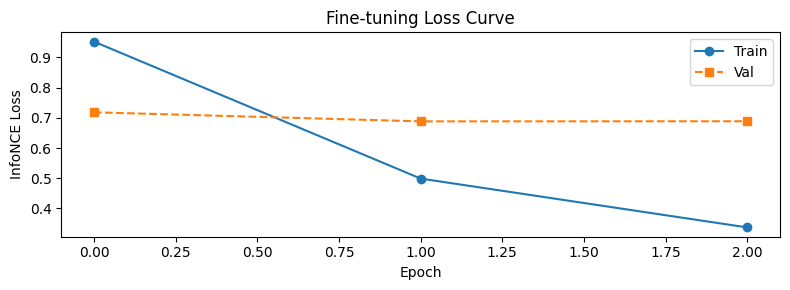

In [33]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses, marker="o", label="Train")
plt.plot(val_losses,   marker="s", label="Val", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("InfoNCE Loss")
plt.title("Fine-tuning Loss Curve"); plt.legend(); plt.tight_layout(); plt.show()


---
## 7 · FAISS Index

**FAISS** (Facebook AI Similarity Search) enables sub-millisecond nearest-neighbour search over millions of vectors.

We use `IndexFlatIP` — **exact inner product search** on L2-normalised vectors (= exact cosine search). For millions of docs, switch to `IndexIVFPQ` for approximate search.

Steps:
1. Encode all corpus passages → matrix of embeddings `(M, D)`
2. Add to FAISS index
3. At query time: encode query → search index for top-K


In [34]:
try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    print("faiss not installed — skipping FAISS sections (pip install faiss-cpu)")
    FAISS_AVAILABLE = False

# Build a small corpus from val set positive passages
corpus_texts = [t["positive"] for t in triples[split:]]
corpus_ids   = list(range(len(corpus_texts)))
EMBED_DIM = 256

def encode_corpus(texts: list[str], model: BiEncoder,
                  tokenizer, batch_size: int = 32) -> np.ndarray:
    """Encode a list of texts → numpy array (N, D)."""
    model.eval()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        enc = tokenizer(
            batch_texts,
            max_length=MAX_P_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            emb = model.encode(
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device),
            )
        all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs).astype("float32")


corpus_embs = encode_corpus(corpus_texts, model, tokenizer)
print(f"Corpus embeddings: {corpus_embs.shape}")

if FAISS_AVAILABLE:
    index = faiss.IndexFlatIP(EMBED_DIM)   # Inner Product on normalised vecs = cosine
    index.add(corpus_embs)
    print(f"FAISS index: {index.ntotal} vectors indexed")


Corpus embeddings: (500, 256)
FAISS index: 500 vectors indexed


---
## 8 · Evaluation: Recall@K and MRR

### Recall@K

$$\text{Recall@K} = \frac{1}{|Q|}\sum_{i=1}^{|Q|} \mathbf{1}[\text{positive}_i \in \text{top-}K(q_i)]$$

What fraction of queries have their positive passage in the top-K retrieved results?

### Mean Reciprocal Rank (MRR)

$$\text{MRR} = \frac{1}{|Q|}\sum_{i=1}^{|Q|} \frac{1}{\text{rank}_i}$$

Average of the reciprocal rank of the first correct result. More sensitive to where the positive appears in the ranked list.


In [ ]:
def evaluate_retrieval(queries: list[str], relevant_ids: list[int],
                       index, model: BiEncoder, tokenizer,
                       k_values: list[int] = [1, 5, 10]) -> dict:
    """
    Encode queries, retrieve top-max(k) from index, compute Recall@K and MRR.

    relevant_ids[i] = corpus index of the positive passage for query i.
    """
    max_k = max(k_values)

    # Encode all queries
    q_embs = encode_corpus(queries, model, tokenizer)   # (Q, D)

    # FAISS search
    _, retrieved_ids = index.search(q_embs, max_k)      # (Q, max_k)

    # Compute metrics
    reciprocal_ranks = []
    hits = {k: 0 for k in k_values}

    for i, rel_id in enumerate(relevant_ids):
        retrieved = retrieved_ids[i].tolist()
        # Recall@K
        for k in k_values:
            if rel_id in retrieved[:k]:
                hits[k] += 1
        # MRR
        if rel_id in retrieved:
            rank = retrieved.index(rel_id) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)

    Q = len(queries)
    results = {f"Recall@{k}": hits[k] / Q for k in k_values}
    results["MRR"] = float(np.mean(reciprocal_ranks))
    return results


if FAISS_AVAILABLE:
    val_queries  = [t["query"]    for t in triples[split:]]
    # The positive for val example i is corpus index i (same order)
    val_rel_ids  = list(range(len(val_queries)))

    metrics = evaluate_retrieval(val_queries, val_rel_ids, index, model, tokenizer)
    print("Retrieval evaluation on val set:")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.4f}")
else:
    print("FAISS not available — skip evaluation.")


---
## 9 · Interactive Query Demo

Type any question and retrieve the top-5 most relevant passages from the indexed corpus.


In [ ]:
def retrieve(query: str, k: int = 5) -> list[dict]:
    """Retrieve top-k passages for a free-text query."""
    if not FAISS_AVAILABLE:
        print("FAISS not available."); return []

    q_emb = encode_corpus([query], model, tokenizer)    # (1, D)
    scores, ids = index.search(q_emb, k)

    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], ids[0]), start=1):
        results.append({
            "rank":    rank,
            "score":   float(score),
            "passage": corpus_texts[idx],
        })
    return results


# --- Try it out ---
query = "What causes thunder?"

print(f"Query: {query}\n{'─'*60}")
for r in retrieve(query, k=5):
    print(f"[{r['rank']}] score={r['score']:.4f}")
    print(f"    {r['passage'][:160]}...")
    print()


---
## Summary & Research Questions

You've now built a complete **dense retrieval pipeline** from scratch:

| Step | What we did |
|------|-------------|
| Data | Loaded MS MARCO triples |
| Tokenisation | HuggingFace AutoTokenizer |
| Model | Bi-encoder BERT + mean pooling + projection head |
| Loss | InfoNCE with in-batch + hard negatives |
| Training | AdamW + linear warmup + mixed precision |
| Indexing | FAISS `IndexFlatIP` |
| Evaluation | Recall@K, MRR |

### Research questions to explore

1. **Pooling strategy** — replace mean pooling with `[CLS]` or max pooling. Does Recall@10 change?
2. **Temperature τ** — try τ ∈ {0.01, 0.05, 0.07, 0.2}. What's the sweet spot?
3. **Hard negatives** — instead of random in-batch negatives, mine BM25 top-100 near-misses. How much does MRR improve?
4. **BM25 baseline** — run `rank_bm25` on the same corpus. How does your fine-tuned BERT compare on out-of-domain queries?
